<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/class_skill_morph_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, PolynomialFeatures, StandardScaler
# Importing mutual_info_classif instead of MutualInformationClassifier
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold

df = pd.read_csv('/content/drive/MyDrive/Dataset/employee_attrition_dataset.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


In [4]:
df.shape, df.dtypes.value_counts()


((1000, 26),
 int64     20
 object     6
 Name: count, dtype: int64)

In [5]:
from sklearn.preprocessing import LabelEncoder

# Encode target: Yes=1, No=0
df['Attrition'] = LabelEncoder().fit_transform(df['Attrition'])

# Keep only numeric columns for simplicity
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Attrition')

X = df[num_cols]
y = df['Attrition']
X.columns.tolist()

['Employee_ID',
 'Age',
 'Job_Level',
 'Monthly_Income',
 'Hourly_Rate',
 'Years_at_Company',
 'Years_in_Current_Role',
 'Years_Since_Last_Promotion',
 'Work_Life_Balance',
 'Job_Satisfaction',
 'Performance_Rating',
 'Training_Hours_Last_Year',
 'Project_Count',
 'Average_Hours_Worked_Per_Week',
 'Absenteeism',
 'Work_Environment_Satisfaction',
 'Relationship_with_Manager',
 'Job_Involvement',
 'Distance_From_Home',
 'Number_of_Companies_Worked']

In [6]:
# Operational metric 1: Income per Year of employment tracking compensation velocity
X['income_per_year'] = X['Monthly_Income'] / (X['Years_at_Company'] + 1)

# Operational metric 2: Loyalty dynamics relative to industry footprint
X['loyalty_ratio'] = X['Years_at_Company'] / (X['Age'] - 18).clip(lower=1)

print("Engineered Domain Framework Features Preview:")
X[['income_per_year', 'loyalty_ratio']].head()

Engineered Domain Framework Features Preview:


,income_per_year,loyalty_ratio
0,968.000000,0.375000
1,1868.428571,0.200000
2,549.760000,1.500000
3,619.000000,1.111111
4,340.200000,1.318182


In [7]:
# Selecting core experiential drivers to produce interaction terms
poly_targets = ['Age', 'Monthly_Income', 'Job_Satisfaction']
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
poly_array = poly.fit_transform(X[poly_targets])

# Standardizing names and merging back into base array
poly_cols = poly.get_feature_names_out(poly_targets)
poly_df = pd.DataFrame(poly_array, columns=poly_cols, index=X.index)

# Dropping the duplicate source columns to avoid redundancy
X = pd.concat([X.drop(columns=poly_targets, errors='ignore'), poly_df], axis=1)
print(f"Total shape after cross-feature interaction generation: {X.shape}")

Total shape after cross-feature interaction generation: (1000, 25)


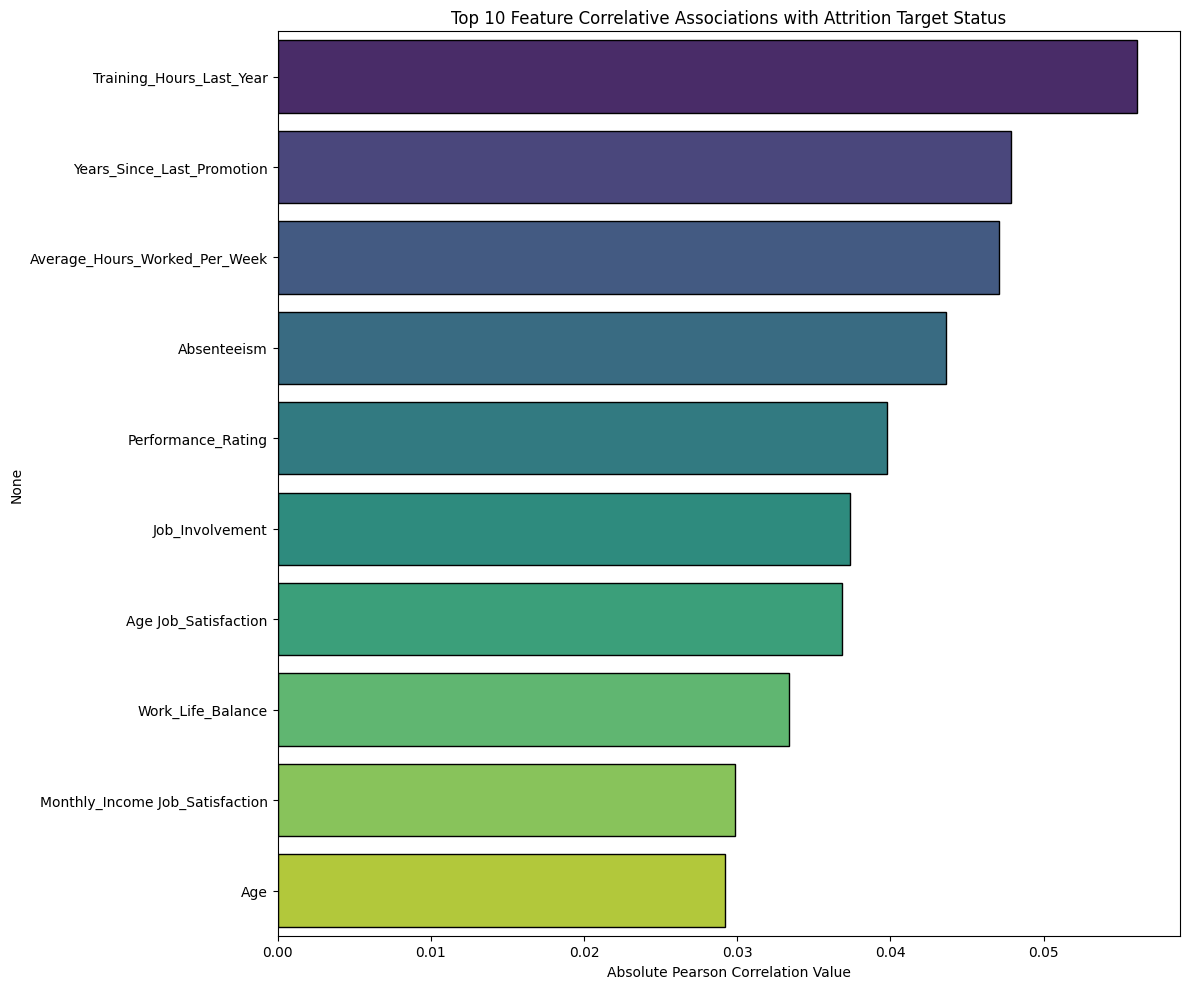

In [8]:
plt.figure(figsize=(12, 10))
corr_matrix = pd.concat([X, y], axis=1).corr()

# Isolate top absolute correlation dependencies relative to Attrition target
top_corr = corr_matrix['Attrition'].drop('Attrition').abs().sort_values(ascending=False).head(10)

sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis', edgecolor='black')
plt.title('Top 10 Feature Correlative Associations with Attrition Target Status')
plt.xlabel('Absolute Pearson Correlation Value')
plt.tight_layout()
plt.show()

selected_corr_features = top_corr.index.tolist()

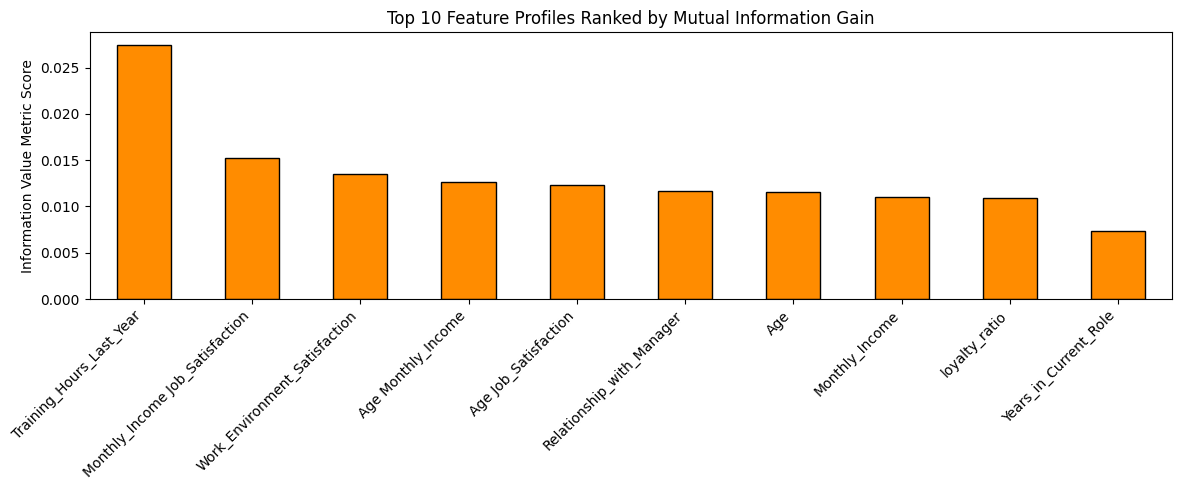

In [23]:
#  Computing non-linear dependency profiles via entropy estimations function
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
mi_series.head(10).plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Top 10 Feature Profiles Ranked by Mutual Information Gain')
plt.ylabel('Information Value Metric Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

selected_mi_features = mi_series.head(5).index.tolist()

In [24]:
# Standardize numerical scales for structural convergence inside Logistic Estimators
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)

rfe_selector = RFE(estimator=LogisticRegression(max_iter=2000, random_state=42), n_features_to_select=5)
rfe_selector.fit(X_scaled, y)

selected_rfe_features = X.columns[rfe_selector.support_].tolist()
print("Top 5 Wrapper Features Isolated via Recursive RFE Elimination:")
print(selected_rfe_features)

Top 5 Wrapper Features Isolated via Recursive RFE Elimination:
['Training_Hours_Last_Year', 'Job_Satisfaction', 'Age Monthly_Income', 'Age Job_Satisfaction', 'Monthly_Income Job_Satisfaction']


In [26]:
# 1. Lasso L1 regularized structural zeroing tracking
lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, y)
lasso_coefs = pd.Series(lasso.coef_, index=X.columns)

# Check if all coefficients are zero. If yes, take the top 5 largest magnitudes anyway.
if (lasso_coefs == 0).all():
    print(" Lasso shrunk all features to zero. Extracting the top 5 largest absolute coefficients as a fallback.")
    selected_lasso_features = lasso_coefs.abs().sort_values(ascending=False).head(5).index.tolist()
else:
    selected_lasso_features = lasso_coefs[lasso_coefs != 0].abs().sort_values(ascending=False).head(5).index.tolist()

# 2. Random Forest Information Gain Gini Tracking
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X, y)
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
selected_rf_features = rf_importance.head(5).index.tolist()

print("\nTop 5 Embedded Features via Lasso Coefficient Selection:", selected_lasso_features)
print("Top 5 Embedded Features via Tree Splitting Criteria:", selected_rf_features)

 Lasso shrunk all features to zero. Extracting the top 5 largest absolute coefficients as a fallback.

Top 5 Embedded Features via Lasso Coefficient Selection: ['Employee_ID', 'Job_Level', 'Hourly_Rate', 'Years_at_Company', 'Years_in_Current_Role']
Top 5 Embedded Features via Tree Splitting Criteria: ['Monthly_Income Job_Satisfaction', 'Age Monthly_Income', 'loyalty_ratio', 'Training_Hours_Last_Year', 'income_per_year']


=== Cross-Validation Accuracy Strategy Benchmark ===
All Extracted Features         -> Mean Accuracy: 0.8100 (± Standard Dev: 0.0032)
Mutual Information Subset      -> Mean Accuracy: 0.7997 (± Standard Dev: 0.0136)
Recursive Elimination (RFE)    -> Mean Accuracy: 0.7950 (± Standard Dev: 0.0128)
Lasso Regularization Set       -> Mean Accuracy: 0.8030 (± Standard Dev: 0.0060)
Tree Importance Array          -> Mean Accuracy: 0.8043 (± Standard Dev: 0.0106)


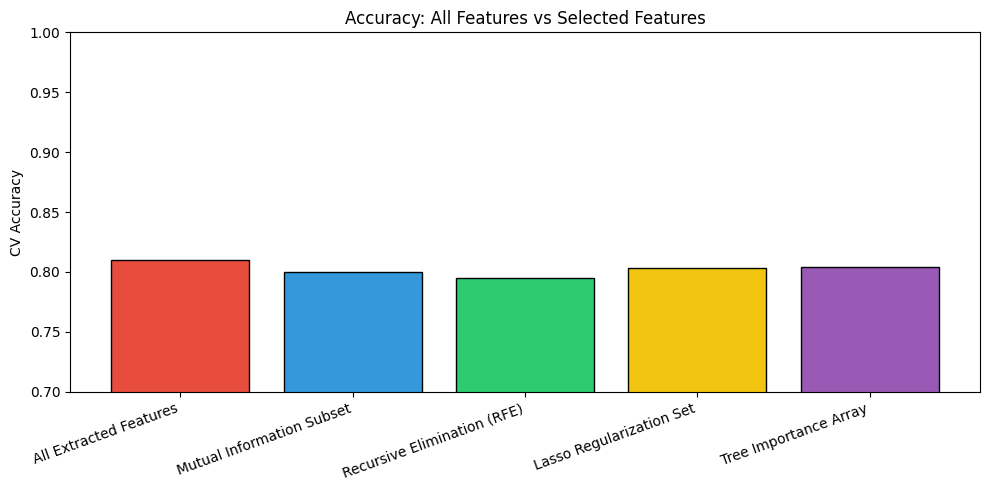

In [28]:
# Initialize testing baseline engine matching class configurations
benchmark_estimator = RandomForestClassifier(n_estimators=100, random_state=42)
cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

feature_sets = {
    'All Extracted Features': X.columns.tolist(),
    'Mutual Information Subset': selected_mi_features,
    'Recursive Elimination (RFE)': selected_rfe_features,
    'Lasso Regularization Set': selected_lasso_features,
    'Tree Importance Array': selected_rf_features
}

# Create an empty list to capture data for the plot
results_list = []

print("=== Cross-Validation Accuracy Strategy Benchmark ===")
for test_name, columns_subset in feature_sets.items():
    if len(columns_subset) == 0:
        print(f"{test_name:<30} -> ⚠️ Skipped: No features selected.")
        continue

    scores = cross_val_score(benchmark_estimator, X[columns_subset], y, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
    mean_accuracy = scores.mean()
    print(f"{test_name:<30} -> Mean Accuracy: {mean_accuracy:.4f} (± Standard Dev: {scores.std():.4f})")

    # Append the method name and accuracy score to our list
    results_list.append({
        'Method': test_name,
        'Accuracy': mean_accuracy
    })

# Convert the list into the 'results' DataFrame your plotting code expects
results = pd.DataFrame(results_list)

# --- YOUR PLOTTING CODE (With a dynamic color palette matching your methods) ---
plt.figure(figsize=(10, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f1c40f', '#9b59b6']

plt.bar(results['Method'], results['Accuracy'], color=colors[:len(results)], edgecolor='black')
plt.ylim(0.7, 1.0)
plt.title('Accuracy: All Features vs Selected Features')
plt.ylabel('CV Accuracy')
plt.xticks(rotation=20, ha='right')  # Tilts text so long method names don't overlap
plt.tight_layout()
plt.show()